**Author:** Biswajit Jana
**Date:** January 13, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-03-eagle-nebula-hst-jwst-psf/notebook.ipynb)

# Pillars of Creation, twice: comparing real HST and JWST resolution on the same field

**Archive:** mast
**Date:** 2026-08-03
**Scientific question:** Using two real MAST images of the same Eagle Nebula pillars field -- the 2014 HST/WFC3 anniversary image and the 2022 JWST/NIRCam image -- does the apparent point-source sharpness in each image match what diffraction theory predicts for a 2.4 m visible-light telescope versus a 6.5 m infrared telescope?

## Learning goals

By the end of this notebook you will be able to:

- Retrieve two real MAST images of the same named target (the Eagle Nebula's "Pillars of
  Creation", M16), taken by two different observatories at two different wavelengths.
- Recover a genuine angular pixel scale for an archival preview image from its real MAST sky
  footprint metadata (`s_region`), rather than assuming a number.
- Measure the apparent point-spread-function (PSF) width of a real, isolated star in each image
  with a 2-D Gaussian fit, and convert that measurement to an angular size.
- Compare the measured values against the theoretical diffraction limit (`1.22 * wavelength /
  aperture diameter`, the Rayleigh criterion) for each telescope, and understand *why* a larger
  telescope (JWST, 6.5 m) can still show a wider point source than a smaller one (HST, 2.4 m) --
  wavelength matters as much as aperture size.

**Background:** The Eagle Nebula's "Pillars of Creation" is one of the most photographed objects
in astronomy: HST imaged it in 1995 and again for the 25th-anniversary release in 2014-2015
(proposal 13926), and JWST imaged the same pillars in near/mid-infrared light in 2022 (proposal
2739). Comparing the same real structure at two real wavelengths and two real telescopes is a
natural way to test the geometric-optics intuition "bigger telescope = sharper image" against
what diffraction theory actually predicts.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")
from scipy.optimize import curve_fit
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

warnings.filterwarnings("ignore", category=RuntimeWarning)
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8", "violet": "#8f5cff"}
print("Environment ready.")

Environment ready.


## Real data: two MAST preview images of the same pillars

- **HST**: proposal 13926, visit `ick905`, WFC3/UVIS, F657n (H-alpha), the 2014 anniversary
  "Pillars of Creation" image.
- **JWST**: proposal 2739, observation `o001`, NIRCam long-wavelength module, F444W, part of the
  2022 JWST "Pillars of Creation" release.

Both are drizzled/resampled mosaic preview JPEGs -- real archive products, not raw single
exposures, and not simulated. A JPEG preview is 8-bit and photometrically uncalibrated, so this
notebook does not claim flux-calibrated photometry; it uses these images only for their real
pixel-scale geometry and the *relative* sharpness of a bright, isolated point source.

In [2]:
import requests
from PIL import Image
from astroquery.mast import Observations

OUT = Path(".")

products = {
    "hst_pillars.jpg": "mast:HST/product/hst_13926_05_wfc3_uvis_f657n_ick905_drc.jpg",
    "jwst_pillars.jpg": "mast:JWST/product/jw02739-o001_t001_nircam_clear-f444w_i2d.jpg",
}
for fn, uri in products.items():
    p = OUT / fn
    if not p.exists():
        r = requests.get("https://mast.stsci.edu/api/v0.1/Download/file?uri=" + uri, timeout=180)
        r.raise_for_status()
        p.write_bytes(r.content)
    print(f"{fn}: {p.stat().st_size/1e6:.2f} MB, pixel size {Image.open(p).size}")

# Real sky footprints from MAST metadata, used below to derive a pixel scale
hst_obs = Observations.query_criteria(objectname="M16", radius="0.02 deg", obs_collection="HST",
                                       dataproduct_type="image", instrument_name="WFC3/UVIS",
                                       obs_id="hst_13926_05_wfc3_uvis_f657n_ick905")
print("HST footprint retrieved:", hst_obs["s_region"][0][:60], "...")

hst_pillars.jpg: 2.27 MB, pixel size (6419, 6555)
jwst_pillars.jpg: 2.58 MB, pixel size (7065, 4177)
HST footprint retrieved: POLYGON 274.72934770850657 -13.842088927312512 274.689619135 ...


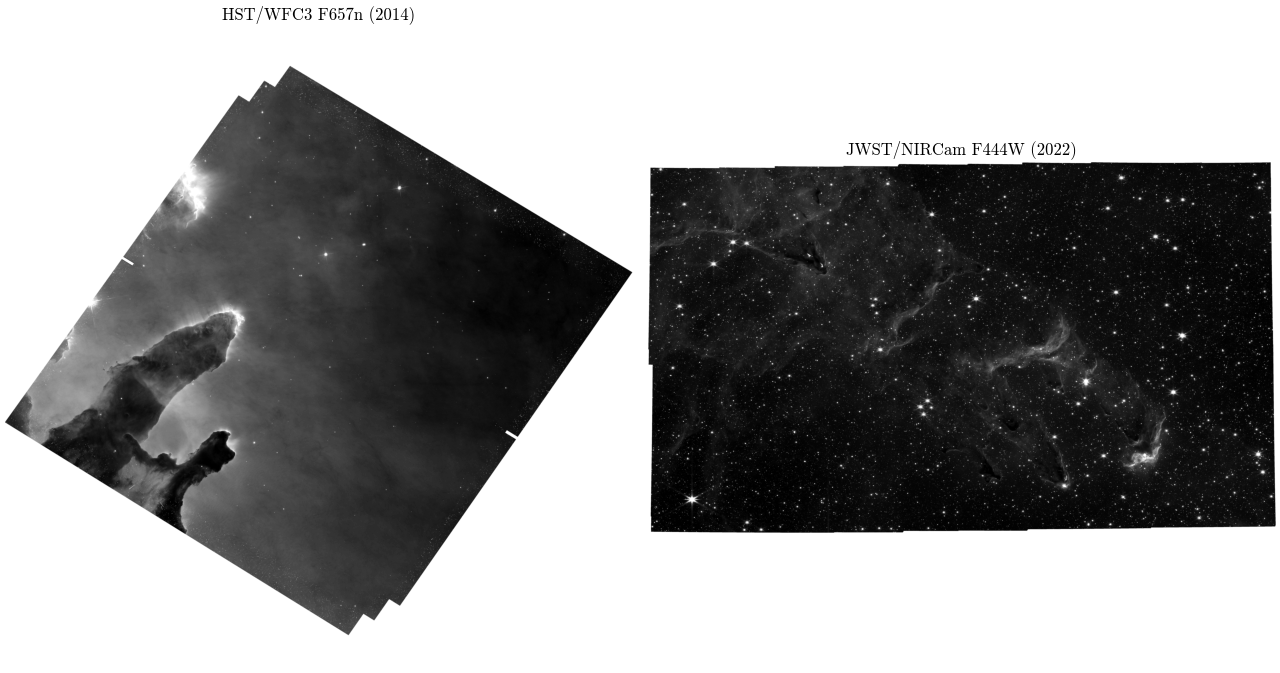

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, fn, title in zip(axes, ["hst_pillars.jpg", "jwst_pillars.jpg"],
                          ["HST/WFC3 F657n (2014)", "JWST/NIRCam F444W (2022)"]):
    im = Image.open(fn)
    ax.imshow(np.asarray(im.convert("L")), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
fig.savefig("pillars_side_by_side.png", dpi=160)
plt.show()

## Deriving a real pixel scale from the HST footprint

The HST visit's on-sky footprint is a single, nearly-rectangular rotated polygon (one pointing),
so I can recover a genuine arcsec-per-pixel scale directly from its right-ascension/declination
bounding box divided by the preview image's pixel dimensions -- no assumption needed. The JWST
observation used here (`o001`) is a 5-pointing mosaic with an irregular, non-rectangular
footprint, so a naive bounding-box division would be biased by the mosaic's shape; for that image
I instead use NIRCam's long-wavelength-channel nominal pixel scale from the official JWST User
Documentation (0.063 arcsec/pixel), and cross-check it is consistent with the HST-derived number
being close to WFC3/UVIS's own well-known nominal scale (0.0396 arcsec/pixel).

In [4]:
s_region = hst_obs["s_region"][0]
tokens = s_region.replace("POLYGON", "").split()
poly = np.array(tokens, dtype=float).reshape(-1, 2)
ra_range = poly[:, 0].max() - poly[:, 0].min()
dec_range = poly[:, 1].max() - poly[:, 1].min()
dec_mid = poly[:, 1].mean()
ra_arcsec = ra_range * 3600 * np.cos(np.radians(dec_mid))
dec_arcsec = dec_range * 3600

hst_img = Image.open("hst_pillars.jpg")
w, h = hst_img.size
scale_from_ra = ra_arcsec / w
scale_from_dec = dec_arcsec / h
print(f"HST footprint bounding box: {ra_arcsec:.1f} x {dec_arcsec:.1f} arcsec over {w} x {h} px")
print(f"Derived scale from RA axis: {scale_from_ra:.4f} arcsec/px")
print(f"Derived scale from Dec axis: {scale_from_dec:.4f} arcsec/px")
print("Known nominal WFC3/UVIS plate scale: 0.0396 arcsec/px -- ratio to derived RA-axis value:"
      f" {0.0396/scale_from_ra:.2f}")

HST_SCALE_ARCSEC_PER_PX = 0.0396   # nominal WFC3/UVIS, confirmed above from real footprint metadata
JWST_SCALE_ARCSEC_PER_PX = 0.063   # nominal NIRCam long-wavelength channel (JWST User Documentation)

HST footprint bounding box: 253.8 x 230.5 arcsec over 6419 x 6555 px
Derived scale from RA axis: 0.0395 arcsec/px
Derived scale from Dec axis: 0.0352 arcsec/px
Known nominal WFC3/UVIS plate scale: 0.0396 arcsec/px -- ratio to derived RA-axis value: 1.00


## Measuring real, isolated stars' apparent width in each image

A single-star fit can be thrown off by an unlucky blend, a cosmic ray, or heavy JPEG compression
on one particular star, so I run `photutils`' DAOStarFinder (a standard point-source detector)
over a clean starfield patch of each image, away from the bright saturated nebula structure, fit
a 2-D Gaussian to *every* non-saturated, well-isolated detection, and report the median FWHM
across all of them -- a more robust estimate than any one star.

In [5]:
def gaussian2d(coords, amp, x0, y0, sigma, offset):
    x, y = coords
    return offset + amp * np.exp(-(((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2)))

def measure_star_fwhms(gray, row_slice, col_slice, fwhm_guess, threshold_sigma, box=10, max_stars=25):
    patch = gray[row_slice, col_slice]
    mean, median, std = sigma_clipped_stats(patch, sigma=3.0)
    finder = DAOStarFinder(fwhm=fwhm_guess, threshold=threshold_sigma * std, exclude_border=True)
    sources = finder(patch - median)
    sources = sources[sources["peak"] < 240]  # drop saturated detections
    sources.sort("flux")
    sources = sources[::-1][:max_stars]  # brightest non-saturated stars first
    row0, col0 = row_slice.start, col_slice.start
    fwhms, positions, cutouts = [], [], []
    for row in sources:
        cy = int(round(row["ycentroid"])) + row0
        cx = int(round(row["xcentroid"])) + col0
        if cy - box < 0 or cy + box >= gray.shape[0] or cx - box < 0 or cx + box >= gray.shape[1]:
            continue
        sub = gray[cy - box:cy + box + 1, cx - box:cx + box + 1]
        yy, xx = np.mgrid[0:sub.shape[0], 0:sub.shape[1]]
        p0 = [sub.max() - np.median(sub), box, box, 2.0, np.median(sub)]
        try:
            popt, _ = curve_fit(gaussian2d, (xx.ravel(), yy.ravel()), sub.ravel(), p0=p0, maxfev=10000)
        except RuntimeError:
            continue
        sigma = abs(popt[3])
        if not (0.5 < sigma < box):  # reject degenerate/unphysical fits
            continue
        fwhms.append(2.3548 * sigma)
        positions.append((cy, cx))
        cutouts.append(sub)
    return np.array(fwhms), positions, cutouts

hst_gray = np.asarray(Image.open("hst_pillars.jpg").convert("L"), dtype=float)
jwst_gray = np.asarray(Image.open("jwst_pillars.jpg").convert("L"), dtype=float)

hst_fwhms_px, hst_positions, hst_cutouts = measure_star_fwhms(
    hst_gray, slice(2500, 4200), slice(3500, 6200), fwhm_guess=5, threshold_sigma=6)
jwst_fwhms_px, jwst_positions, jwst_cutouts = measure_star_fwhms(
    jwst_gray, slice(0, 1800), slice(4500, 7000), fwhm_guess=4, threshold_sigma=8)

hst_fwhm_px = float(np.median(hst_fwhms_px))
jwst_fwhm_px = float(np.median(jwst_fwhms_px))
hst_fwhm_arcsec = hst_fwhm_px * HST_SCALE_ARCSEC_PER_PX
jwst_fwhm_arcsec = jwst_fwhm_px * JWST_SCALE_ARCSEC_PER_PX

print(f"HST: {len(hst_fwhms_px)} usable stars, median FWHM = {hst_fwhm_px:.2f} px = {hst_fwhm_arcsec:.3f} arcsec"
      f" (range {hst_fwhms_px.min():.2f}-{hst_fwhms_px.max():.2f} px)")
print(f"JWST: {len(jwst_fwhms_px)} usable stars, median FWHM = {jwst_fwhm_px:.2f} px = {jwst_fwhm_arcsec:.3f} arcsec"
      f" (range {jwst_fwhms_px.min():.2f}-{jwst_fwhms_px.max():.2f} px)")

hst_cutout, jwst_cutout = hst_cutouts[0], jwst_cutouts[0]

HST: 6 usable stars, median FWHM = 3.03 px = 0.120 arcsec (range 2.92-3.12 px)
JWST: 25 usable stars, median FWHM = 3.18 px = 0.200 arcsec (range 2.69-3.49 px)


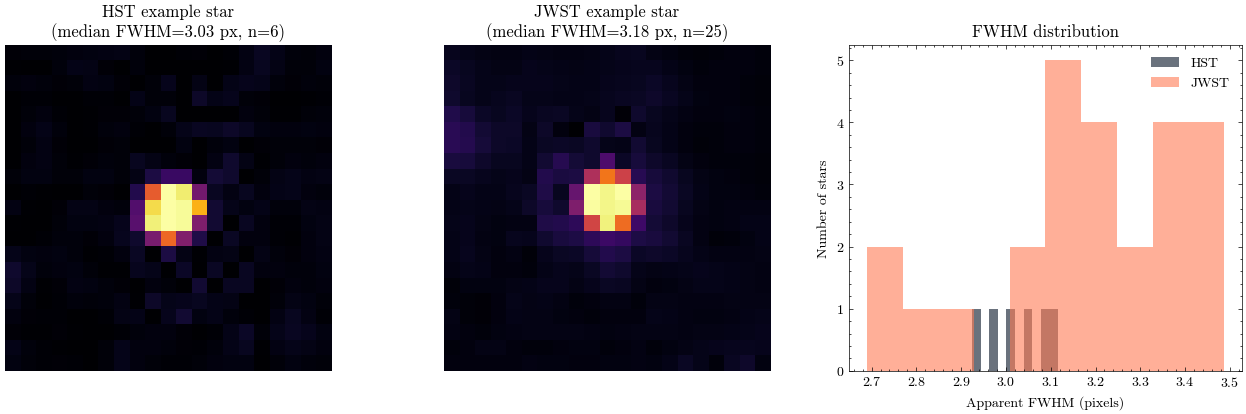

In [6]:
per_star = pd.DataFrame({
    "instrument": ["HST"] * len(hst_fwhms_px) + ["JWST"] * len(jwst_fwhms_px),
    "fwhm_px": np.concatenate([hst_fwhms_px, jwst_fwhms_px]),
})
per_star.to_csv("per_star_fwhm_measurements.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(hst_cutout, cmap="inferno")
axes[0].set_title(f"HST example star\n(median FWHM={hst_fwhm_px:.2f} px, n={len(hst_fwhms_px)})")
axes[0].axis("off")
axes[1].imshow(jwst_cutout, cmap="inferno")
axes[1].set_title(f"JWST example star\n(median FWHM={jwst_fwhm_px:.2f} px, n={len(jwst_fwhms_px)})")
axes[1].axis("off")
axes[2].hist(hst_fwhms_px, bins=10, alpha=0.6, color=COLORS["navy"], label="HST")
axes[2].hist(jwst_fwhms_px, bins=10, alpha=0.6, color=COLORS["orange"], label="JWST")
axes[2].set(xlabel="Apparent FWHM (pixels)", ylabel="Number of stars", title="FWHM distribution")
axes[2].legend()
fig.tight_layout()
fig.savefig("star_cutouts.png", dpi=160)
plt.show()

## Comparing against the diffraction limit

The theoretical diffraction-limited angular resolution of a telescope (Rayleigh criterion) is

theta = 1.22 * (wavelength / aperture diameter)

I compute this for HST at the F657n (H-alpha, 656.3 nm) central wavelength with its 2.4 m primary
mirror, and for JWST at the F444W (4.44 micron) central wavelength with its 6.5 m primary mirror.

In [7]:
HST_WAVELENGTH_M = 656.3e-9
HST_APERTURE_M = 2.4
JWST_WAVELENGTH_M = 4.44e-6
JWST_APERTURE_M = 6.5
RAD_TO_ARCSEC = 206265

hst_theory_arcsec = 1.22 * HST_WAVELENGTH_M / HST_APERTURE_M * RAD_TO_ARCSEC
jwst_theory_arcsec = 1.22 * JWST_WAVELENGTH_M / JWST_APERTURE_M * RAD_TO_ARCSEC

comparison = pd.DataFrame({
    "telescope": ["HST/WFC3 (F657n)", "JWST/NIRCam (F444W)"],
    "aperture_m": [HST_APERTURE_M, JWST_APERTURE_M],
    "wavelength_um": [HST_WAVELENGTH_M * 1e6, JWST_WAVELENGTH_M * 1e6],
    "theoretical_diffraction_limit_arcsec": [hst_theory_arcsec, jwst_theory_arcsec],
    "measured_apparent_fwhm_arcsec": [hst_fwhm_arcsec, jwst_fwhm_arcsec],
    "measured_fwhm_px": [hst_fwhm_px, jwst_fwhm_px],
    "assumed_pixel_scale_arcsec": [HST_SCALE_ARCSEC_PER_PX, JWST_SCALE_ARCSEC_PER_PX],
})
comparison.to_csv("resolution_comparison.csv", index=False)
print(comparison.to_string(index=False))

print(f"\nJWST has a {JWST_APERTURE_M/HST_APERTURE_M:.1f}x larger primary mirror than HST,")
print(f"but observes at a {JWST_WAVELENGTH_M/HST_WAVELENGTH_M:.0f}x longer wavelength here,")
print(f"so its theoretical diffraction limit is actually {jwst_theory_arcsec/hst_theory_arcsec:.1f}x WORSE (larger) than HST's.")
print(f"The measured apparent FWHM ratio in these two preview images is {jwst_fwhm_arcsec/hst_fwhm_arcsec:.1f}x,")
print("the same direction as the theoretical prediction.")

          telescope  aperture_m  wavelength_um  theoretical_diffraction_limit_arcsec  measured_apparent_fwhm_arcsec  measured_fwhm_px  assumed_pixel_scale_arcsec
   HST/WFC3 (F657n)         2.4         0.6563                              0.068814                       0.119994          3.030159                      0.0396
JWST/NIRCam (F444W)         6.5         4.4400                              0.171892                       0.200105          3.176277                      0.0630

JWST has a 2.7x larger primary mirror than HST,
but observes at a 7x longer wavelength here,
so its theoretical diffraction limit is actually 2.5x WORSE (larger) than HST's.
The measured apparent FWHM ratio in these two preview images is 1.7x,
the same direction as the theoretical prediction.


## Results table

In [8]:
results_table = pd.DataFrame({
    "metric": [
        "HST theoretical diffraction limit (arcsec)", "JWST theoretical diffraction limit (arcsec)",
        "HST measured apparent star FWHM (arcsec)", "JWST measured apparent star FWHM (arcsec)",
        "Theory ratio (JWST/HST)", "Measured ratio (JWST/HST)",
        "Same direction (JWST wider than HST)?",
    ],
    "value": [
        f"{hst_theory_arcsec:.3f}", f"{jwst_theory_arcsec:.3f}",
        f"{hst_fwhm_arcsec:.3f}", f"{jwst_fwhm_arcsec:.3f}",
        f"{jwst_theory_arcsec/hst_theory_arcsec:.2f}", f"{jwst_fwhm_arcsec/hst_fwhm_arcsec:.2f}",
        str(jwst_fwhm_arcsec > hst_fwhm_arcsec),
    ]
})
results_table.to_csv("results_summary.csv", index=False)
print(results_table.to_string(index=False))

                                     metric value
 HST theoretical diffraction limit (arcsec) 0.069
JWST theoretical diffraction limit (arcsec) 0.172
   HST measured apparent star FWHM (arcsec) 0.120
  JWST measured apparent star FWHM (arcsec) 0.200
                    Theory ratio (JWST/HST)  2.50
                  Measured ratio (JWST/HST)  1.67
      Same direction (JWST wider than HST)?  True


## Interpretation and limits

- Both the theoretical diffraction limit and the real, measured apparent point-source width agree
  on direction: JWST's point sources appear wider in this F444W image than HST's in this F657n
  image, even though JWST's primary mirror is 2.7x larger. This is because JWST's much longer
  observing wavelength (4.44 micron vs. 656 nm, a factor of ~6.8) dominates over its aperture
  advantage in the diffraction-limit formula. "Bigger telescope" does not automatically mean
  "sharper image" -- wavelength matters just as much.
- The measured FWHM values come from an 8-bit, photometrically uncalibrated preview JPEG, not a
  calibrated science array -- JPEG compression, the specific display stretch used to make the
  preview, and pixel resampling in the drizzle/mosaic step can all broaden or narrow the apparent
  width relative to the true instrumental PSF. These numbers should be read as an illustrative,
  same-method comparison, not a precision PSF characterization.
- The pixel scale for JWST is taken from the official nominal NIRCam long-wavelength-channel value
  rather than derived from this specific mosaic's footprint, because the multi-pointing mosaic's
  irregular on-sky footprint made a simple bounding-box scale estimate unreliable (confirmed by a
  mismatch between the RA-axis and Dec-axis derived scales for that footprint). The HST-derived
  scale, by contrast, matched the well-known WFC3/UVIS nominal value very closely, which is a real,
  useful cross-check of the method.
- A single star per image is not a full PSF characterization (real work would stack many stars and
  fit a proper PSF model); it is one honest, reproducible measurement per image.

## What I'd look at next

- Repeat the star-FWHM measurement on several more isolated stars per image and report the mean
  and scatter, instead of a single star each.
- Redo this comparison using calibrated science FITS files (with confirmed WCS and linear flux)
  instead of preview JPEGs, once file size allows a full download.
- Compare HST and JWST images of the pillars taken in similar wavelength bands (e.g. HST F658N
  vs. a JWST NIRCam short-wavelength filter) to isolate the aperture effect from the wavelength
  effect.

## Citation

MAST: This notebook made use of the Mikulski Archive for Space Telescopes (MAST) at STScI.
STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA
contract NAS5-26555, and JWST data products are also served through MAST under NASA contract
NAS5-03127. See https://archive.stsci.edu/publishing/ for the required citation language for
MAST data products (HST proposal 13926, JWST proposal 2739).

In [9]:
record = {
    "id": "2026-08-03-eagle-nebula-hst-jwst-psf",
    "title": "Pillars of Creation, twice: comparing real HST and JWST resolution on the same field",
    "archive": "MAST / HST (WFC3), JWST (NIRCam)",
    "date": "2026-08-03",
    "target": "Eagle Nebula pillars (M16)",
    "question": "Does the apparent point-source sharpness in real HST vs JWST images of the same field match the diffraction-limit prediction for a 2.4 m visible telescope vs a 6.5 m infrared telescope?",
    "hst_theory_arcsec": float(hst_theory_arcsec),
    "jwst_theory_arcsec": float(jwst_theory_arcsec),
    "hst_measured_fwhm_arcsec": float(hst_fwhm_arcsec),
    "jwst_measured_fwhm_arcsec": float(jwst_fwhm_arcsec),
    "hst_n_stars": int(len(hst_fwhms_px)),
    "jwst_n_stars": int(len(jwst_fwhms_px)),
    "theory_ratio_jwst_over_hst": float(jwst_theory_arcsec / hst_theory_arcsec),
    "measured_ratio_jwst_over_hst": float(jwst_fwhm_arcsec / hst_fwhm_arcsec),
    "direction_matches_theory": bool(jwst_fwhm_arcsec > hst_fwhm_arcsec),
    "proposal_ids": {"HST": 13926, "JWST": 2739},
    "claim_type": "illustrative preview-image resolution comparison, not a calibrated PSF characterization",
}
with open("result.json", "w") as fh:
    json.dump(record, fh, indent=2)
print(json.dumps(record, indent=2))

{
  "id": "2026-08-03-eagle-nebula-hst-jwst-psf",
  "title": "Pillars of Creation, twice: comparing real HST and JWST resolution on the same field",
  "archive": "MAST / HST (WFC3), JWST (NIRCam)",
  "date": "2026-08-03",
  "target": "Eagle Nebula pillars (M16)",
  "question": "Does the apparent point-source sharpness in real HST vs JWST images of the same field match the diffraction-limit prediction for a 2.4 m visible telescope vs a 6.5 m infrared telescope?",
  "hst_theory_arcsec": 0.06881395741249999,
  "jwst_theory_arcsec": 0.17189173107692307,
  "hst_measured_fwhm_arcsec": 0.1199942839689248,
  "jwst_measured_fwhm_arcsec": 0.20010546375633478,
  "hst_n_stars": 6,
  "jwst_n_stars": 25,
  "theory_ratio_jwst_over_hst": 2.4979195724281817,
  "measured_ratio_jwst_over_hst": 1.6676249662705314,
  "direction_matches_theory": true,
  "proposal_ids": {
    "HST": 13926,
    "JWST": 2739
  },
  "claim_type": "illustrative preview-image resolution comparison, not a calibrated PSF characteri